Use CompareMotionNoMotion to plot images

In [1]:
__version__ = '0.2.0'

# import engine module
import sirf.Gadgetron as pMR
from sirf.Utilities import examples_data_path
# from sirf_exercises import exercises_data_pathtoken
import sirf.Reg as pReg


from cil.framework import  AcquisitionGeometry, BlockDataContainer, BlockGeometry
from cil.optimisation.functions import Function, OperatorCompositionFunction, SmoothMixedL21Norm, L1Norm, L2NormSquared, BlockFunction, MixedL21Norm, IndicatorBox, TotalVariation, LeastSquares, ZeroFunction
from cil.optimisation.operators import GradientOperator, BlockOperator, ZeroOperator, CompositionOperator,LinearOperator
from cil.optimisation.algorithms import PDHG, FISTA, GD, SPDHG
from cil.plugins.ccpi_regularisation.functions import FGP_TV

# import further modules
import os
import numpy as np
import scipy.signal as sp_signal

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

import functools
import cil
import sirf

assert cil.version.version == '23.1.0'
print (sirf.__version__)
assert sirf.__version__ == '3.6.0'

3.6.0


In [2]:
# Plotting function
data_path = '/home/jovyan/work/SIRF-Contribs/src/notebooks/'
os.chdir(data_path)
import utils
from utils import plot_rpe_3d, plot_rpe_3d_simple, save_itrobj
print ("Ciao")


Ciao


In [3]:
import importlib
importlib.reload(utils)
from utils import plot_rpe_3d, plot_rpe_3d_simple, saveCallback, add_HORIZONTAL_phase_shift, plot_rpe_3d_simple_dir

In [4]:
############# SETUP #################
# number of motion states
Nms = 3
# max
max_shift = 20.
# setup linear shifts
shifts = np.linspace(0, 1, Nms) * max_shift

## Recon parameters
n_epochs = 100
# factor in front of L2Norm
omega = 0.5
# regularisation parameter
alpha = 2e-5

In [5]:
# data_path = exercises_data_path('MR')

filename = os.path.join(data_path, '3D_GRPE_no_motion.h5')

In [6]:
# Load in the data
acq_data = pMR.AcquisitionData(filename)
acq_data.sort_by_time()

reading from /home/jovyan/work/SIRF-Contribs/src/notebooks/3D_GRPE_no_motion.h5 using ignore mask 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 

Started reading acquisitions from /home/jovyan/work/SIRF-Contribs/src/notebooks/3D_GRPE_no_motion.h5
0%..10%..20%..31%..40%..50%..61%..70%..80%..90%..
Finished reading acquisitions from /home/jovyan/work/SIRF-Contribs/src/notebooks/3D_GRPE_no_motion.h5


In [7]:
csm = pMR.CoilSensitivityData()
csm.smoothness = 100
csm.calculate(acq_data) 

E = pMR.AcquisitionModel(acqs=acq_data, imgs=csm)
E.set_coil_sensitivity_maps(csm)


In [8]:
## Adding Horizontal Phase Shifts 
### Create Motion States

import importlib
importlib.reload(utils)

from utils import split_data_with_horizontal_shifts, create_AcquisitionModel_for_each_motion_state 

acq_ms = split_data_with_horizontal_shifts(acq_data, shifts)

E_ms = create_AcquisitionModel_for_each_motion_state(acq_ms, csm)



In [9]:
# reconstruct without accounting for motion
import functools
from tqdm import tqdm
from cil.optimisation.functions import SumFunction
im_fista_ms = [0] * Nms

im_ms = E_ms[0].inverse(acq_ms[0])



A = BlockOperator(*E_ms)

acq_ms_block = BlockDataContainer(*acq_ms)

SumFi = SumFunction(*[LeastSquares(Ai, bi, c=omega) for Ai,bi in zip(A.operators, acq_ms)])
# Starting image
x_init = im_ms.clone()
x_init.fill(0.0)

# Objective function
# f = LeastSquares(E_ms[ind], acq_ms[ind], c=1)
G = ZeroFunction()

# Set up FISTA for least squares
fista = FISTA(initial=x_init, f=SumFi, g=G)
fista.max_iteration = 100
fista.update_objective_interval = 5

# Run FISTA
# sc = functools.partial(saveCallback, fista, f"FISTA_L2_ms_{ind}", os.path.join(data_path, recons, f'MS_{Nms}'))
# fista.run(20, verbose=1, callback=sc)
fista.run(20, verbose=1)

# Get result
im_fista_motion_no_mcir = fista.solution

     Iter   Max Iter     Time/Iter            Objective
                               [s]                     
        0        100         0.000          1.69328e-02
        5        100        23.546          2.04207e-03
       10        100        23.601          1.29131e-03
       15        100        23.650          1.20639e-03
       20        100        23.662          1.18198e-03
-------------------------------------------------------
       20        100        23.662          1.18198e-03
Stop criterion has been reached.



In [10]:
# save result
recons2k = "recons_ignore-acq_4tris"
# os.makedirs(os.path.join(data_path, recons2k, f'MS_{Nms}'))
savefname = os.path.join(data_path, recons2k, f'MS_{Nms}', 'im_fista_motion_no_mcir.h5')
im_fista_motion_no_mcir.write(savefname)

In [11]:
### Reconstruct without motion
import functools
from tqdm import tqdm
im_fista_ms = [0] * Nms

# max
max_shift_no_motion = 0.
# setup linear shifts
shifts_no_motion = np.linspace(0, 1, Nms) * max_shift_no_motion
acq_ms_no_motion = split_data_with_horizontal_shifts(acq_data, shifts_no_motion)
E_ms_no_motion = create_AcquisitionModel_for_each_motion_state(acq_ms_no_motion, csm)

im_ms = E_ms_no_motion[0].inverse(acq_ms_no_motion[0])


F_all_subs_no_motion = []
for Ai, bi in zip(E_ms_no_motion, acq_ms_no_motion):
    F_all_subs_no_motion.append(LeastSquares(Ai,bi, c=omega))
    
# F = BlockFunction(*F_all_subs_no_motion)

SumFi_no_motion = SumFunction(*F_all_subs_no_motion)

# Starting image
x_init = im_ms.clone()
# x_init.fill(0.0)

# Objective function
G = ZeroFunction()

# Set up FISTA for least squares
fista = FISTA(initial=x_init, f=SumFi_no_motion, g=G)
fista.max_iteration = 100
fista.update_objective_interval = 5

# Run FISTA
# sc = functools.partial(saveCallback, fista, f"FISTA_L2_ms_{ind}", os.path.join(data_path, recons, f'MS_{Nms}'))
# fista.run(20, verbose=1, callback=sc)
fista.run(20, verbose=1)

# norm = E.norm()

# # Starting image
# x_init = im_ms.clone()
# # x_init.fill(0.0)

# # Objective function
# f = LeastSquares(E, acq_data, c=1)
# G = ZeroFunction()

# # Set up FISTA for least squares
# fista = FISTA(initial=x_init, f=f, g=G)
# fista.max_iteration = 100
# fista.update_objective_interval = 5

# # Run FISTA
# # sc = functools.partial(saveCallback, fista, f"FISTA_L2_ms_{ind}", os.path.join(data_path, recons, f'MS_{Nms}'))
# # fista.run(20, verbose=1, callback=sc)
# fista.run(20, verbose=0)
    
# Get result
im_fista_no_motion = fista.solution
# save result
savefname = os.path.join(data_path, recons2k, f'MS_{Nms}', 'im_fista_no_motion.h5')
im_fista_no_motion.write(savefname)

     Iter   Max Iter     Time/Iter            Objective
                               [s]                     
        0        100         0.000          1.65336e-02
        5        100        21.364          1.15142e-03
       10        100        21.519          2.05629e-04
       15        100        21.465          1.03228e-04
       20        100        21.730          8.34215e-05
-------------------------------------------------------
       20        100        21.730          8.34215e-05
Stop criterion has been reached.



/home/jovyan/work/SIRF-Contribs/src/notebooks/utils.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


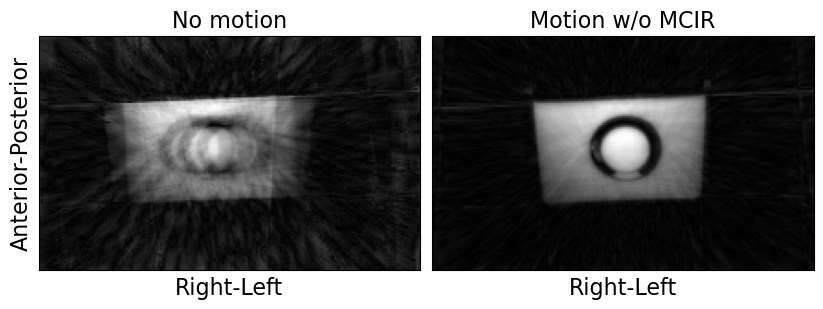

In [14]:
# increase the font size
# https://matplotlib.org/stable/users/explain/customizing.html
import matplotlib
# import matplotlib.pylab as pylab
params = {'axes.titlesize':'16', 'axes.labelsize':'16'}
# matplotlib.rcParams.update(matplotlib.rcParamsDefault)
# matplotlib.rcParams.update({'font.size': 14})
matplotlib.rcParams.update(params)

plot_rpe_3d_simple_dir([im_fista_motion_no_mcir.as_array(), im_fista_no_motion.as_array()], 
                   [64, 64],
                   ['No motion', 'Motion w/o MCIR'], hspace=0.2, wspace = 0.03, 
                      fig_name="compare-motion-nomotion-nomcir")
                       #, fig_name="motion_state_example")